In [1]:
# import packages

from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

### Data Preparation

The dataset is imported and assessed for missing values. The identifier variable (`UNITID`) is excluded from analysis, and the remaining features are used as inputs.

A preprocessing pipeline is applied in which missing values are imputed using median substitution, followed by standardization to zero mean and unit variance. The resulting feature matrix (`X`) is thus suitable for subsequent analyses requiring normalized, complete numerical inputs.

Normalization is particularly important for k-means clustering, as the algorithm relies on distance-based calculations. Without standardization, variables with larger scales may disproportionately influence cluster formation, leading to biased or misleading groupings.

In [2]:
df = pd.read_csv('data/PCA (optional)/Sample Dataset.csv')

In [3]:
df.isna().sum()

UNITID                        0
FIRST_YEAR_RET_RATE          94
GRAD_RATE_WITHIN_150         11
COMP_TRAN_RATE                8
OUTCOME_EFFICIENCY_INDEX    147
FALL_ENROLLMENT_TOTAL         0
dtype: int64

In [4]:
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
X_raw = df.drop('UNITID',axis=1)
unitid = df['UNITID']
X = pipeline.fit_transform(X_raw)

### K-Means Clustering and Cluster Selection

K-means clustering is applied across a range of cluster sizes (k = 2 to 99) to evaluate model fit and determine an appropriate number of clusters. For each value of k, both standard K-means and MiniBatch K-means are fit, and model performance is assessed using inertia and silhouette scores.



In [5]:
k = 100

n_k = []
inertia = []
mini_inertia = []
sil_score = []


for K in range(2,k):
    kmeans = KMeans(n_clusters=K, n_init=10)
    minibatch_kmeans = MiniBatchKMeans(n_clusters=K, n_init=10)
    kmeans.fit(X)
    minibatch_kmeans.fit(X)
    n_k.append(K)
    inertia.append(kmeans.inertia_)
    mini_inertia.append(minibatch_kmeans.inertia_)
    sil_score.append(silhouette_score(X, kmeans.labels_))

The **elbow method** is used to examine inertia, which measures within-cluster sum of squares. As k increases, inertia decreases; however, the point at which the rate of decrease sharply diminishes (the “elbow”) indicates a suitable balance between model complexity and explanatory power. In parallel, the **silhouette score** is evaluated to assess cluster separation and cohesion, with higher values indicating more well-defined clusters. Together, these metrics inform the selection of k = 8.



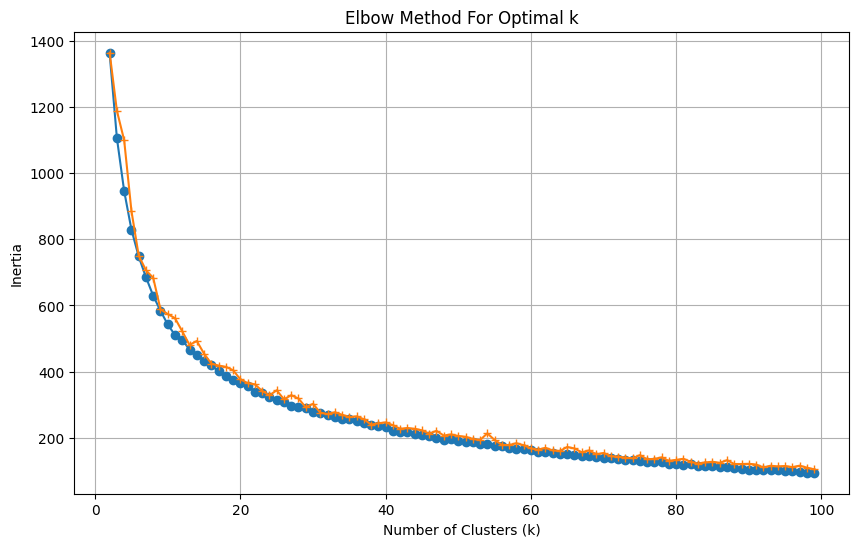

In [6]:
# Plotting the elbow curve
plt.figure(figsize=(10, 6))
plt.plot(n_k, inertia, marker='o',)
plt.plot(n_k, mini_inertia, marker='+')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.grid(True)
plt.show()

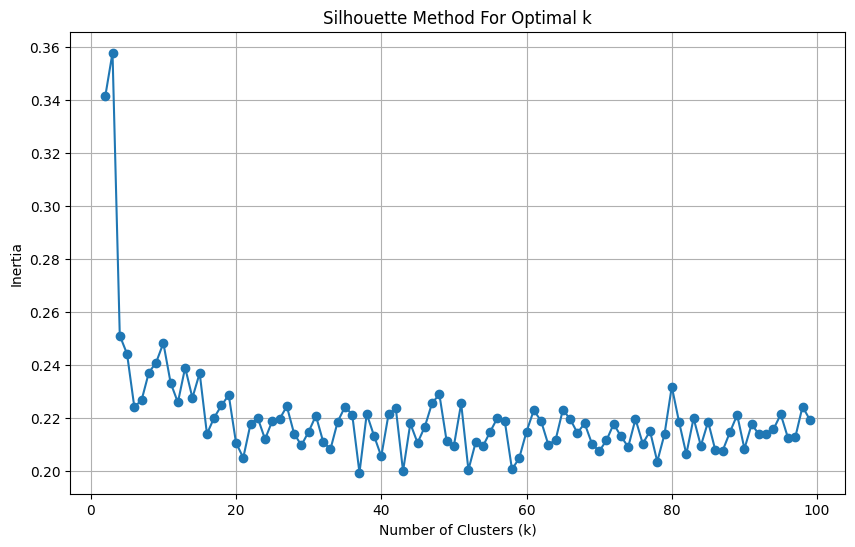

In [7]:
plt.figure(figsize=(10, 6))
plt.plot(n_k, sil_score, marker='o',)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Silhouette Method For Optimal k')
plt.grid(True)
plt.show()

In [8]:
kmeans = KMeans(n_clusters=8, n_init=10, random_state=10)
minibatch_kmeans = MiniBatchKMeans(n_clusters=K, n_init=10)
y_pred = kmeans.fit_predict(X)

After fitting the final model, cluster assignments are appended to the dataset. The specific cluster label corresponding to our institution (UNITID = 156107) is identified (e.g., cluster “7”) to anchor interpretation of cluster groupings. In your application you should use your own Institution ID. Additionally, the row index associated with this institution (e.g., index “95”) is retained to facilitate subsequent similarity analysis, such as cosine similarity comparisons relative to this reference point.

In [9]:
X_clustered = pd.DataFrame(X, columns=X_raw.columns)
X_clustered['cluster'] = y_pred
X_clustered['unitid'] = unitid
X_clustered[X_clustered['unitid']==156107]

,FIRST_YEAR_RET_RATE,GRAD_RATE_WITHIN_150,COMP_TRAN_RATE,OUTCOME_EFFICIENCY_INDEX,FALL_ENROLLMENT_TOTAL,cluster,unitid
95,0.021102,-0.023943,0.07168,1.708271,0.78693,7,156107


### Principal Component Analysis (PCA) and Cluster Visualization

Principal Component Analysis (PCA) is applied to reduce the high-dimensional feature space to two components, enabling visualization of cluster structure. The initial plot displays cluster centroids (mean positions) in the reduced space, providing a clear, aggregated view of spatial relationships between clusters. This is particularly useful for identifying how the reference cluster (e.g., cluster “7”) relates to others in terms of proximity.



In [10]:
n_components = 2#len(df.columns) - 1
pca = PCA(n_components=n_components)
principle_components = pca.fit_transform(X)

pca_df = pd.DataFrame(principle_components, columns=[f"PC{i+1}" for i in range(n_components)])
pca_df['cluster'] = y_pred
explained_variance = pca.explained_variance_ratio_

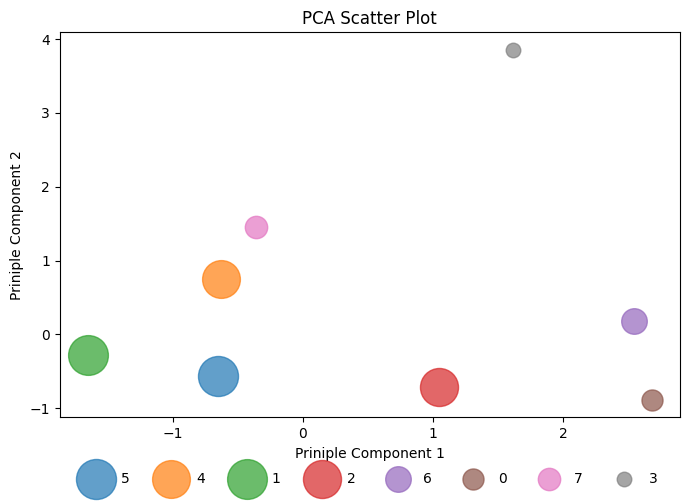

In [11]:
plt.figure(figsize=(8,5))
for cat in pca_df['cluster'].unique():
    subset = pca_df[pca_df['cluster']==cat]
    plt.scatter(subset['PC1'].mean(), subset['PC2'].mean(), label=str(cat), alpha=0.7, s=len(subset) * 10)

plt.xlabel('Priniple Component 1')

plt.ylabel('Priniple Component 2')
plt.title('PCA Scatter Plot')
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.21), ncol=k, frameon=False)
plt.show()

Cluster labels are then mapped to descriptive categories (e.g., “Our WSUT Cluster”, “Closest Cluster”) to support interpretation and communication of results.



In [12]:
# Define the mapping
label_mapping = {
    7: 'Our WSUT Cluster',
    4: 'Closest Cluster',
    5: 'Intermediate Cluster',
    1: 'Far Cluster',
    2: 'Farthest Cluster',
    6: 'Remote Cluster 1',
    0: 'Remote Cluster 2',
    3: 'Remote Cluster 3'
}

# Apply the mapping
y_pred_labels = np.array([label_mapping[val] for val in y_pred])


A second visualization plots all individual observations without aggregation. This highlights the inherent overlap and dispersion within clusters, demonstrating that while PCA aids interpretation, true separation between groups is not always distinct. As such, PCA should be considered a supplementary tool rather than definitive evidence in peer selection.



In [13]:
n_components = 2#len(df.columns) - 1
pca = PCA(n_components=n_components)
principle_components = pca.fit_transform(X)

pca_df = pd.DataFrame(principle_components, columns=[f"PC{i+1}" for i in range(n_components)])
pca_df['cluster'] = y_pred_labels
explained_variance = pca.explained_variance_ratio_

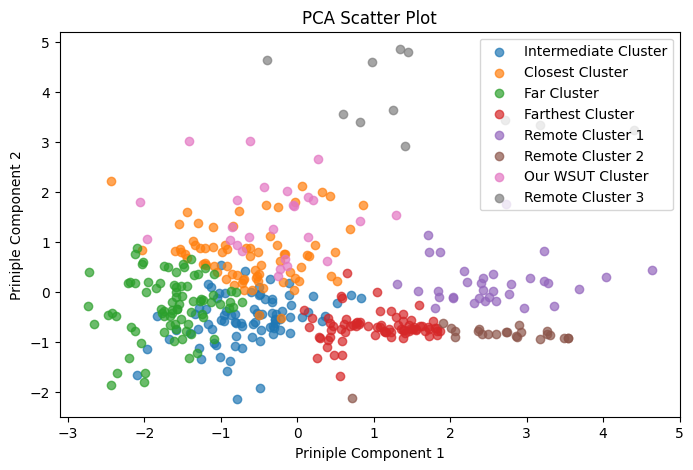

In [14]:
plt.figure(figsize=(8,5))
for cat in pca_df['cluster'].unique():
    subset = pca_df[pca_df['cluster']==cat]
    plt.scatter(subset['PC1'], subset['PC2'], label=str(cat), alpha=0.7)

plt.xlabel('Priniple Component 1')

plt.ylabel('Priniple Component 2')
plt.title('PCA Scatter Plot')
plt.legend()
plt.show()

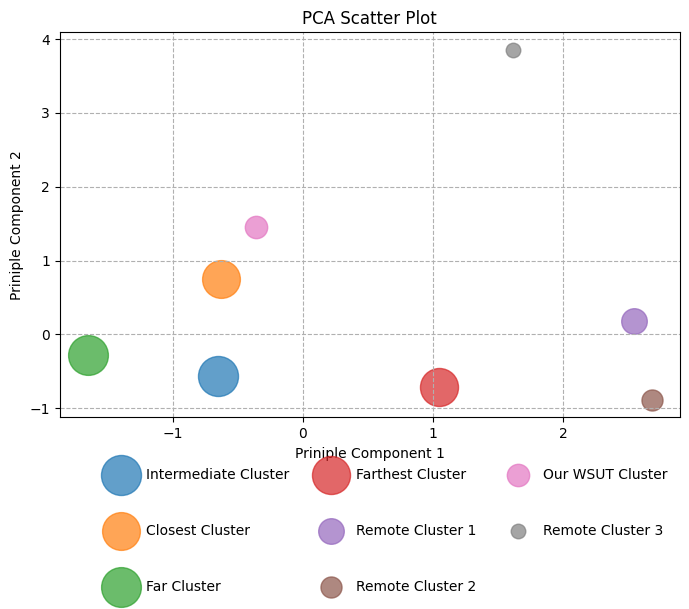

In [15]:
plt.figure(figsize=(8,5))
for cat in pca_df['cluster'].unique():
    subset = pca_df[pca_df['cluster']==cat]
    plt.scatter(subset['PC1'].mean(), subset['PC2'].mean(), label=str(cat), alpha=0.7, s=len(subset) * 10)

plt.xlabel('Priniple Component 1')
plt.grid(linestyle='--')
plt.ylabel('Priniple Component 2')
plt.title('PCA Scatter Plot')
plt.legend(bbox_to_anchor=(1, -0.1, 0, 0), 
           ncol=3, 
           frameon=False, 
           labelspacing=3)
plt.show()

Finally, the derived cluster labels are appended to the original dataset to support downstream analysis and interpretation.

In [16]:
final_df = df.copy(deep=True)
final_df['cluster'] = y_pred_labels

### Cosine Similarity and Cluster-Based Ranking

Cosine similarity is computed to quantify the relative similarity of each institution to the reference institution (UNITID = 156107). Using the corresponding feature vector (index 95), similarity scores are calculated between this reference point and all other observations in the dataset. A value of 1 indicates identical orientation in feature space, serving as a baseline for comparison.

In [17]:
# Below I am using index 95 in this dataset which is unitid = 156107 
# and finding the cosine similarity between all other points
similarity = [cosine_similarity(X[95].reshape(1, -1),X[i].reshape(1, -1)) for i in range(len(X))]
similarity = [similarity[i][0][0] for i in range(len(similarity))]


The resulting similarity scores are appended to the dataset. Cluster labels are then converted to an ordered categorical variable to enforce a meaningful hierarchy (e.g., from “Our WSUT Cluster” to more remote clusters).

Finally, the dataset is sorted first by cluster grouping and then by similarity in descending order. This produces a structured ranking of institutions, where peers within closer clusters and higher similarity are prioritized. The reference institution is expected to have a similarity score of 1.

In [18]:
final_df['similarity'] = similarity
label_order = [
    'Our WSUT Cluster',
    'Closest Cluster',
    'Intermediate Cluster',
    'Far Cluster',
    'Farthest Cluster',
    'Remote Cluster 1',
    'Remote Cluster 2',
    'Remote Cluster 3'
]
final_df['cluster'] = pd.Categorical(
    final_df['cluster'],
    categories=label_order,
    ordered=True
)
final_df = final_df.sort_values(
    by=['cluster', 'similarity'],
    ascending=[True, False]
)

In [19]:
# Similarity for our school should be 1
final_df.head()

,UNITID,FIRST_YEAR_RET_RATE,GRAD_RATE_WITHIN_150,COMP_TRAN_RATE,OUTCOME_EFFICIENCY_INDEX,FALL_ENROLLMENT_TOTAL,cluster,similarity
95,156107,0.564103,0.43,0.432306,2.965620,6106,Our WSUT Cluster,1.000000
55,139384,0.526804,0.43,0.487765,3.218133,7282,Our WSUT Cluster,0.978136
59,140243,0.570278,0.34,0.404817,3.166505,6908,Our WSUT Cluster,0.977358
244,218885,0.540070,0.42,0.396406,2.602344,5890,Our WSUT Cluster,0.975950
334,434061,0.507772,0.30,0.342764,4.357716,6238,Our WSUT Cluster,0.944979


In [20]:
final_df.to_csv('data/PCA (optional)/PCA Output.csv', index=False)